### [자동차 연비 관련 분석] 

- 데이터 : auto_mpg.csv
- 특징
    - 1993년도 미국의 자동차 연비 분석을 위해 수집된 데이터
    - 9개의 컬럼 (1개 타겟 , 8개 피쳐)
    - 다변량 데이터셋

---

[1] 모듈 로딩 및 데이터 준비 <hr>


In [36]:
##  모듈 로딩
import pandas as pd

In [37]:
## 데이터 선정
DATA_FILE = '../../DATA/auto_mpg.csv'

[2] CSV => DataFrame 로딩 및 기본 정보 확인 <hr>

In [38]:
## DF 인스턴스 생성
## [기본] 1. header = 0 , sep = ','
mpgDF = pd.read_csv(DATA_FILE)

In [39]:
## 기본 요약 정보 => info 메서드
mpgDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [40]:
# <class 'pandas.core.frame.DataFrame'>
# RangeIndex: 398 entries, 0 to 397
# Data columns (total 9 columns):
# -----------------------------------------------------------------------------------------------------------------
# 기초 전처리
# -----------------------------------------------------------------------------------------------------------------
#  #   Column        Non-Null Count  Dtype  
# ---  ------        --------------  -----  
#  0   mpg           398 non-null    float64
#  1   cylinders     398 non-null    int64  
#  2   displacement  398 non-null    float64
#  3   horsepower    398 non-null    object      => '130' 또는 믹싱
#  4   weight        398 non-null    int64  
#  5   acceleration  398 non-null    float64
#  6   model year    398 non-null    int64       => 실제로는 년도이지만 정수로 표기됨  => 좀 더 확인 필요  => 정수 X
#  7   origin        398 non-null    int64       =>    제조국     =>  범주형이지만 정수로 표기되어 있음
#  8   car name      398 non-null    object 
# -----------------------------------------------------------------------------------------------------------------
# dtypes: float64(3), int64(4), object(2)
# memory usage: 28.1+ KB

In [41]:
## 모든 컬럼의 기초 통계값 확인 => describe()
mpgDF.describe(include='all')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
count,398.000000,398.000000,398.000000,398,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,94,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,150,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,22,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,NaN,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,NaN,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,NaN,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,NaN,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,NaN,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,NaN,3608.000000,17.175000,79.000000,2.000000,NaN


In [42]:
#  1   cylinders     398 non-null    int64    => 얘는 연속적이지 않음! ( 범주형임 )

In [43]:
## 실제 데이터 일부 확인 head() / tail()
mpgDF.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite


[3] 기초 전처리 <hr>
- 결측치 / 중복값 체크
- 컬럼별 자료형 일치

In [44]:
## [3-1] 결측치 : isnull() / isna() -> 원소마다 검사
mpgDF.isna().sum()


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [45]:
## [3-2] 중복 데이터 검사 : duplicated()
mpgDF.duplicated().sum()


np.int64(0)

In [46]:
## [3-3] 컬럼별 자료형 변환 - horsepower
## => horsepower 컬럼 object >>> int
mpgDF['horsepower'].value_counts()['?']

np.int64(6)

In [54]:
## => 마력은 숫자 데이터인데 이상한 ? 데이터 : 이상치
## 이상치가 있는 행 번호 추출

drop_index = mpgDF[mpgDF['horsepower']== '?'].index

## =>  object >>> int로 형변환
mpgDF['horsepower']= mpgDF['horsepower'].astype('int')

In [55]:
# => 이상치가 행 삭제 진행
mpgDF = mpgDF.drop(index = drop_index).reset_index(drop=True)

In [56]:
## [3-3] 컬럼별 자료형 변환 - model_year, cylinders, origin 칼럼
## model_year, cyliders, origin int64 >> 범주형
## 고유값
## - 값의 종류
## Series에 제공되는 메서드 unique()
## 고유값 확인 즉, 컬럼별 값의 종류 체크
for col in ['cylinders', 'origin', 'model year']:
    print(f'{col:10} ===> {mpgDF[col].unique()}')


cylinders  ===> [8, 4, 6, 3, 5]
Categories (5, int64): [3, 4, 5, 6, 8]
origin     ===> [1, 3, 2]
Categories (3, int64): [1, 2, 3]
model year ===> [70, 71, 72, 73, 74, ..., 78, 79, 80, 81, 82]
Length: 13
Categories (13, int64): [70, 71, 72, 73, ..., 79, 80, 81, 82]


In [57]:
## int >>> 범주형 형변환
for col in ['cylinders', 'origin', 'model year']:
    mpgDF[col] = mpgDF[col].astype('category')

In [58]:
## 자료형 확인
mpgDF.dtypes

mpg              float64
cylinders       category
displacement     float64
horsepower         int64
weight             int64
acceleration     float64
model year      category
origin          category
car name          object
dtype: object

In [66]:
## [3-4] 컬럼별 자료형 변환 - 연속형/수치형 >>> 범주형
## - 숫자값을 일정 구간으로 나누어서 이해가 쉽도록 만들어주는 방법
## - 예) 연령대 : 1,3,6,12 ====> 10대, 20대 , 30대 ===> 청년, 중년, 장년, 노년
## - 함수 : pandas.cut()
## 마력/출력 => 저출력, 일반출력, 고출력 : 범위 조사
retSR = pd.cut( x = mpgDF['horsepower'], 
                bins = 3, 
                labels=['저출력', '일반출력', '고출력'])

## 현재 DF에 새로운 컬럼으로 추가
mpgDF['horsepower_label'] = retSR
mpgDF.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,horsepower_label
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,일반출력
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,일반출력
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,일반출력


[4] 연비 mpg 컬럼과 관련성이 있는 속성/피쳐 <hr>
- 타겟 컬럼/속성 : mpg
- 피처 컬럼/변수 : 나머지 컬럼들
- 상관계수 활용 
    - 컬럼들의 관계/선형 정도를 수치화
    - 값의 범위 : -1 ~ 1
    - 음의 상관관계 / 양의 상관관계
    - ★ 인과관계는 아니다!!
    - ★ 완벽한 선형이 아닌 경우 값이 -1 또는 1에 가까운 값이 나오지 않을 수도 있음
    - 반드시 시각화를 통해서 컬럼들을 결정지어야 함!!
    

In [59]:
## mpg 컬럼과 관련성이 있는 정도를 체크하는 메서드 : corr()
mpgDF.corr(numeric_only=True)

,mpg,displacement,horsepower,weight,acceleration
mpg,1.000000,-0.805127,-0.778427,-0.832244,0.423329
displacement,-0.805127,1.000000,0.897257,0.932994,-0.543800
horsepower,-0.778427,0.897257,1.000000,0.864538,-0.689196
weight,-0.832244,0.932994,0.864538,1.000000,-0.416839
acceleration,0.423329,-0.543800,-0.689196,-0.416839,1.000000


In [77]:
## mpg 컬럼만 추출
corrSR = mpgDF.corr(numeric_only=True)['mpg'] # .abs()
corrSR.index[1:]

Index(['displacement', 'horsepower', 'weight', 'acceleration'], dtype='object')

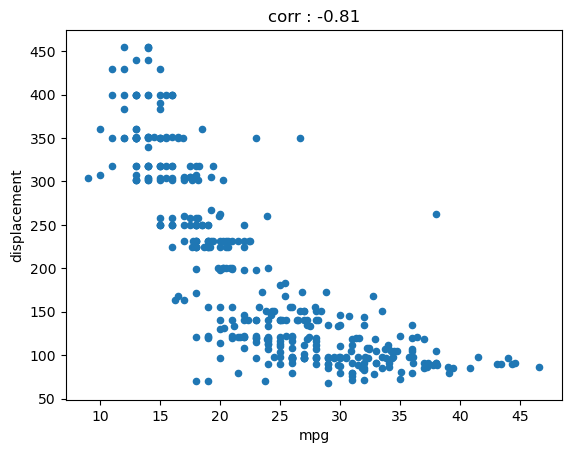

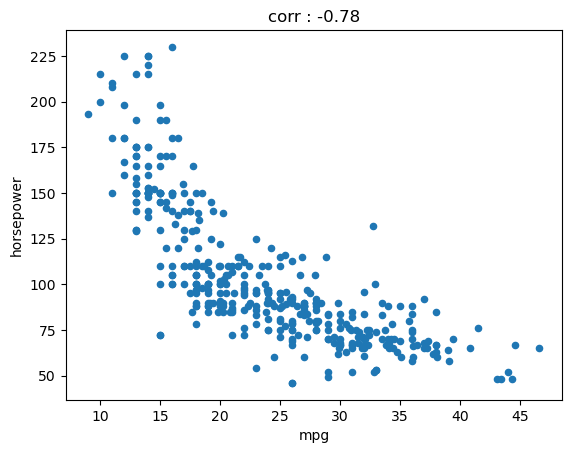

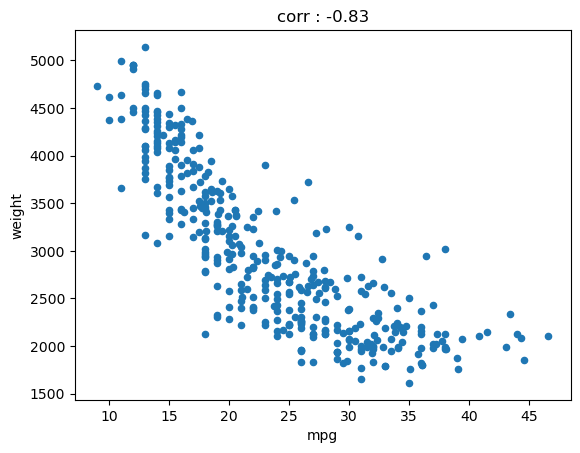

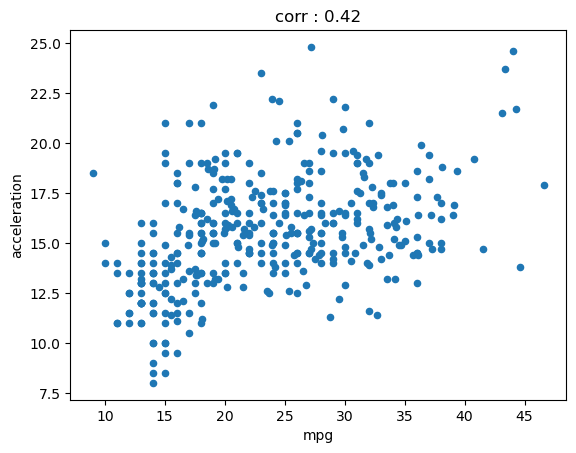

In [79]:
## mpg 컬럼과 다른 컬럼과의 관계 시각화
for col in corrSR.index[1:]:
    mpgDF.plot(x='mpg', y= col, kind = 'scatter',title= f'corr : {corrSR[col]:.2f}')